# Hands-on script on Mode-based method and how to download and use Scholarly Migration Database data

### ============================
#### Author details ####
### ============================

### Script's author: Aliakbar Akbaritabar
### Version: 2024-11-05
### Tested: 2026-01-14
### Email: akbaritabar@demogr.mpg.de
### Website: https://www.demogr.mpg.de/en/about_us_6113/staff_directory_1899/aliakbar_akbaritabar_4098/


During the hands-on session, we will use this additional notebook to discuss:
1) How mode-based method in identifying migration events work, 
2) How to download and use the scholarly migration database (SMD) data, 
3) What are the example research questions we can explore using the SMD data?

# How to use the mode-based method for migration?

# Toy example similar to Scopus data

In [1]:
import pandas as pd

# toy example to test

# a sample Pandas dataframe to use with DB

df = pd.DataFrame({
    'row_num': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
    'author_id':[57215334932, 57215334932, 57215334932, 57215334932, 57215334932,57215334932, 57215334932, 57215334932,
                   57203865752, 57203865752, 57203865752, 57203865752, 57203865752,57203865752, 57203865752, 57203865752],
    'pubyear': [2002, 2000, 2001, 2003, 2004, 2010, 2010, 2011, 2000, 2002, 2005, 2007, 2007, 2007, 2009, 2010],
    'countrycode': ['USA', 'USA', 'DEU','DEU', 'GBR', 'USA', 'GBR', 'DEU', 'USA', 'USA', 'DEU','DEU', 'GBR', 'USA', 'GBR', 'DEU']
    })

# sort
df.sort_values(by=['author_id', 'pubyear', 'countrycode'], inplace=True)

In [2]:
df

,row_num,author_id,pubyear,countrycode
8,9,57203865752,2000,USA
9,10,57203865752,2002,USA
10,11,57203865752,2005,DEU
11,12,57203865752,2007,DEU
12,13,57203865752,2007,GBR
13,14,57203865752,2007,USA
14,15,57203865752,2009,GBR
15,16,57203865752,2010,DEU
1,2,57215334932,2000,USA
2,3,57215334932,2001,DEU


In [3]:
dfallgrouped = df.groupby(['author_id','pubyear']).agg(
    countrycodecombinedmode=pd.NamedAgg(column='countrycode', aggfunc=pd.Series.mode)
    )

dfallgrouped.sort_values(by=["author_id","pubyear"],inplace=True)


In [4]:
dfallgrouped

countrycodecombinedmode
author_id   pubyear                        
57203865752 2000                        USA
            2002                        USA
            2005                        DEU
            2007            [DEU, GBR, USA]
            2009                        GBR
            2010                        DEU
57215334932 2000                        USA
            2001                        DEU
            2002                        USA
            2003                        DEU
            2004                        GBR
            2010                 [GBR, USA]
            2011                        DEU

# How to download and use Scholarly Migration Database

In [5]:
import pandas as pd

In [6]:
import plotnine as gg

In [7]:
# copy data download URLs from "https://www.scholarlymigration.org/data.html"
country_data = pd.read_csv(
    "https://github.com/MPIDR/Global-flows-and-rates-of-international-migration-of-scholars/raw/refs/heads/master/data_processed/2024_V1/scopus_2024_V1_scholarlymigration_country_enriched.csv"
)

flow_data = pd.read_csv(
    "https://github.com/MPIDR/Global-flows-and-rates-of-international-migration-of-scholars/raw/refs/heads/master/data_processed/2024_V1/scopus_2024_V1_scholarlymigration_countryflows_enriched.csv"
)


In [8]:
# OpenAlex
op_country = pd.read_parquet(
    "https://github.com/MPIDR/Global-flows-and-rates-of-international-migration-of-scholars/raw/refs/heads/master/data_processed/2024_V1/openalex_2024_V1_scholarlymigration_country_enriched.parquet"
)
op_flow = pd.read_parquet(
    "https://github.com/MPIDR/Global-flows-and-rates-of-international-migration-of-scholars/raw/refs/heads/master/data_processed/2024_V1/openalex_2024_V1_scholarlymigration_countryflows_enriched.parquet"
)

In [9]:
who_ls DataFrame

['country_data', 'df', 'dfallgrouped', 'flow_data', 'op_country', 'op_flow']

In [10]:
country_data

,year,countrycode,padded_population_of_researchers,number_of_inmigrations,number_of_outmigrations,netmigration,outmigrationrate,inmigrationrate,netmigrationrate,iso2code,iso3code,countryname,region,incomelevel,avg_paddedpop,gdp_per_capita,population
0,2000.0,ABW,2,0,0,0,0.000000,0.000000,0.000000,AW,ABW,Aruba,Latin America & Caribbean,HIC,14.714286,20681.023027,90588.0
1,2009.0,ABW,9,0,0,0,0.000000,0.000000,0.000000,AW,ABW,Aruba,Latin America & Caribbean,HIC,14.714286,25134.771230,101604.0
2,2010.0,ABW,11,1,0,1,0.000000,0.090909,0.090909,AW,ABW,Aruba,Latin America & Caribbean,HIC,14.714286,24093.140151,101838.0
3,2011.0,ABW,14,0,0,0,0.000000,0.000000,0.000000,AW,ABW,Aruba,Latin America & Caribbean,HIC,14.714286,25712.384302,102591.0
4,2012.0,ABW,18,1,3,-2,0.166667,0.055556,-0.111111,AW,ABW,Aruba,Latin America & Caribbean,HIC,14.714286,25119.665545,104110.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4735,2020.0,SHN,10,2,2,0,0.200000,0.200000,0.000000,NaN,NaN,NaN,NaN,NaN,10.875000,NaN,NaN
4736,2020.0,FLK,38,6,2,4,0.052632,0.157895,0.105263,NaN,NaN,NaN,NaN,NaN,23.791667,NaN,NaN
4737,2020.0,TWN,87729,1029,1141,-112,0.013006,0.011729,-0.001277,NaN,NaN,NaN,NaN,NaN,58948.642857,NaN,NaN
4738,2020.0,ATA,6,0,2,-2,0.333333,0.000000,-0.333333,NaN,NaN,NaN,NaN,NaN,4.750000,NaN,NaN


In [11]:
flow_data

,n_migrations,year,countrynamefrom,countrynameto,regionfrom,regionto,incomelevelfrom,incomelevelto,gdp_per_capitafrom,gdp_per_capitato,...,paddedpopto,number_of_inmigrationsfrom,number_of_inmigrationsto,number_of_outmigrationsfrom,number_of_outmigrationsto,avg_paddedpopfrom,avg_paddedpopto,avg_paddedpop_min,normalized_migration1,normalized_migration2
0,2,2012.0,Switzerland,"Egypt, Arab Rep.",Europe & Central Asia,"Middle East, North Africa, Afghanistan & Pakistan",HIC,LMC,85836.207677,2996.067707,...,30129,3188,724,2361,609,47243.214286,23543.392857,23543.392857,117.002581,111.551964
1,3,2011.0,"Hong Kong SAR, China",New Zealand,East Asia & Pacific,East Asia & Pacific,HIC,HIC,35142.487934,38431.776679,...,19863,896,638,1064,702,15859.678571,16257.785714,15859.678571,441.935560,817.419424
2,2,2007.0,Slovak Republic,Italy,Europe & Central Asia,Europe & Central Asia,HIC,HIC,16110.481727,37826.175455,...,171867,139,1708,165,2075,9539.000000,167594.178571,9539.000000,709.672841,133.054028
3,1,2012.0,Mali,Morocco,Sub-Saharan Africa,"Middle East, North Africa, Afghanistan & Pakistan",LIC,LMC,878.217175,3164.177246,...,10035,33,212,24,115,514.925926,8654.321429,514.925926,19654.088050,14962.645755
4,7,2020.0,Iraq,India,"Middle East, North Africa, Afghanistan & Pakistan",South Asia,UMC,LMC,4295.189451,1907.042516,...,405022,695,3087,207,5285,4922.107143,183507.000000,4922.107143,1095.446230,74.150557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106328,3,2019.0,Jordan,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan","Middle East, North Africa, Afghanistan & Pakistan",LMC,LIC,4170.114400,633.887202,...,739,281,77,240,34,4027.428571,327.892857,327.892857,16233.766234,42067.771179
106329,13,2004.0,India,Israel,South Asia,"Middle East, North Africa, Afghanistan & Pakistan",LMC,HIC,624.258827,20568.069409,...,28311,829,458,1516,724,183507.000000,30170.535714,30170.535714,1872.313950,465.167530
106330,10,2010.0,India,Bangladesh,South Asia,South Asia,LMC,LMC,1347.519391,757.385280,...,5861,1714,165,2653,206,183507.000000,5882.928571,5882.928571,2284.435002,860.653277
106331,5,2014.0,"Hong Kong SAR, China",Switzerland,East Asia & Pacific,Europe & Central Asia,HIC,HIC,40315.373951,88724.991074,...,65525,1051,3420,1131,2722,15859.678571,47243.214286,15859.678571,129.265102,357.760575


In [12]:
op_country

,year,countrycode,padded_population_of_researchers,number_of_inmigrations,number_of_outmigrations,netmigration,outmigrationrate,inmigrationrate,netmigrationrate,iso2code,iso3code,countryname,region,incomelevel,gdp_per_capita,population
0,1998.0,None,72,7,6,1,0.083333,0.097222,0.013889,None,None,None,None,None,NaN,NaN
1,1998.0,None,5,0,12,-12,2.400000,0.000000,-2.400000,None,None,None,None,None,NaN,NaN
2,1998.0,None,8,0,0,0,0.000000,0.000000,0.000000,None,None,None,None,None,NaN,NaN
3,1998.0,None,116,5,2,3,0.017241,0.043103,0.025862,None,None,None,None,None,NaN,NaN
4,1998.0,None,81,10,4,6,0.049383,0.123457,0.074074,None,None,None,None,None,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4100,2014.0,ZWE,1524,81,78,3,0.051181,0.053150,0.001969,ZW,ZWE,Zimbabwe,Sub-Saharan Africa,LMC,1407.034293,13855753.0
4101,2015.0,ZWE,1652,87,103,-16,0.062349,0.052663,-0.009685,ZW,ZWE,Zimbabwe,Sub-Saharan Africa,LMC,1410.329174,14154937.0
4102,2016.0,ZWE,1726,81,111,-30,0.064311,0.046929,-0.017381,ZW,ZWE,Zimbabwe,Sub-Saharan Africa,LMC,1421.787789,14452704.0
4103,2017.0,ZWE,1785,89,132,-43,0.073950,0.049860,-0.024090,ZW,ZWE,Zimbabwe,Sub-Saharan Africa,LMC,1192.107012,14751101.0


In [13]:
op_flow

,n_migrations,year,countrynamefrom,countrynameto,regionfrom,regionto,incomelevelfrom,incomelevelto,gdp_per_capitafrom,gdp_per_capitato,populationfrom,populationto,iso3codefrom,iso3codeto,paddedpopfrom,paddedpopto
0,30,2003.0,Spain,China,Europe & Central Asia,East Asia & Pacific,HIC,UMC,21510.836245,1288.643252,42187645.0,1.288400e+09,ESP,CHN,98067,256586
1,10,2008.0,United States,Bolivia,North America,Latin America & Caribbean,HIC,LMC,48570.045980,1687.583393,304093966.0,9.880593e+06,USA,BOL,974303,447
2,3360,2014.0,United States,Canada,North America,North America,HIC,HIC,55123.849787,50955.998323,318386329.0,3.543744e+07,USA,CAN,1169891,157838
3,4554,2006.0,United Kingdom,United States,Europe & Central Asia,North America,HIC,HIC,44536.619720,46302.000880,60846820.0,2.983799e+08,GBR,USA,202416,903561
4,16,2014.0,Tunisia,Italy,Middle East & North Africa,Europe & Central Asia,LMC,HIC,4398.573922,35565.721377,11428948.0,6.078914e+07,TUN,ITA,15733,195954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107705,1,2013.0,"Egypt, Arab Rep.",Singapore,Middle East & North Africa,East Asia & Pacific,LMC,HIC,3088.890834,56967.425794,93377890.0,5.399162e+06,EGY,SGP,32885,19623
107706,2,2002.0,Sao Tome and Principe,Portugal,Sub-Saharan Africa,Europe & Central Asia,LMC,HIC,568.411237,12936.692820,149841.0,1.041963e+07,STP,PRT,78,9313
107707,1,1999.0,Nigeria,Belgium,Sub-Saharan Africa,Europe & Central Asia,LMC,HIC,496.030187,25252.801907,119695565.0,1.022642e+07,NGA,BEL,3263,21396
107708,1,2009.0,"Venezuela, RB",Japan,Latin America & Caribbean,East Asia & Pacific,INX,HIC,11641.799147,41308.996837,28327892.0,1.280470e+08,VEN,JPN,5298,259197


In [14]:
country_data.groupby('countrycode')['number_of_inmigrations'].sum().reset_index().rename(columns={'number_of_inmigrations':'sum_inMig'}).sort_values(by='sum_inMig', ascending=False).head(n=20)

,countrycode,sum_inMig
219,USA,430057
73,GBR,170052
53,DEU,134228
39,CHN,117394
69,FRA,99505
35,CAN,96481
12,AUS,70341
37,CHE,61842
105,JPN,61754
62,ESP,50675


In [15]:
country_data.loc[100]

year                                                                           1999.0
countrycode                                                                       ARE
padded_population_of_researchers                                                  707
number_of_inmigrations                                                             70
number_of_outmigrations                                                            42
netmigration                                                                       28
outmigrationrate                                                             0.059406
inmigrationrate                                                               0.09901
netmigrationrate                                                             0.039604
iso2code                                                                           AE
iso3code                                                                          ARE
countryname                                           

# Example research questions 1: Travel ban's effect

In 2017, USA imposed a travel ban on 7 country nationals entrance. Here we briefly look if using the SMD flow data, we can ask:

1. are the flows from these countries to the USA affected by the travel ban?
2. are there alternative countries who might have become the new destination of scholars from those seven countries and experience an increased flow?

## Related literature to check
If you are interested to know more about this topic, check the following references:

- Chinchilla-Rodríguez, Z., Bu, Y., Robinson-García, N., Costas, R., & Sugimoto, C. R. (2018). Travel bans and scientific mobility: Utility of asymmetry and affinity indexes to inform science policy. Scientometrics, 116(1), 569–590. https://doi.org/10.1007/s11192-018-2738-2
- Morello, L., & Reardon, S. (2017). Meet the scientists affected by Trump’s immigration ban. Nature, 542(7639), 13–14. https://doi.org/10.1038/nature.2017.21389
- Stone, R. (2018). Science in Iran languishes after Trump re-imposes sanctions. Science. https://doi.org/10.1126/science.aav2811

In [16]:
flow_data.iso3codefrom.unique()

array(['CHE', 'HKG', 'SVK', 'MLI', 'IRQ', 'TUR', 'NLD', 'SRB', 'USA',
       'ESP', 'KHM', 'CUB', 'LBN', 'BGR', 'SWE', 'MWI', 'JPN', 'MEX',
       'FIN', 'EST', 'ISR', 'BOL', 'CZE', 'PRT', 'HUN', 'RUS', 'SEN',
       'IND', 'AUS', 'VEN', 'SGP', 'ARM', 'FRA', 'GBR', 'ITA', 'CHN',
       'NZL', 'KOR', 'GUY', 'NPL', 'BGD', 'DEU', 'GEO', 'UKR', 'KAZ',
       'NOR', 'MCO', 'MAR', 'POL', 'UZB', 'ARE', 'CAN', 'BRB', 'THA',
       'VNM', 'IDN', 'GRL', 'HRV', 'KEN', 'JAM', 'AUT', 'ROU', 'PRI',
       'IRL', 'CMR', 'BRA', 'URY', 'CHL', 'LUX', 'BHR', 'BEL', 'BFA',
       'MYS', 'EGY', 'ARG', 'NGA', 'ZAF', 'MNG', 'DNK', 'BEN', 'IRN',
       'KWT', 'ETH', 'KNA', 'ISL', 'MKD', 'UGA', 'NIC', 'QAT', 'ECU',
       'JOR', 'MAC', 'MDA', 'TZA', 'LKA', 'MOZ', 'COG', 'MMR', 'YEM',
       'PER', 'DJI', 'ALB', 'PYF', 'AND', 'ZWE', 'LBY', 'BLR', 'SVN',
       'GHA', 'NAM', 'SYR', 'LTU', 'TUN', 'GRC', 'SAU', 'LIE', 'OMN',
       'ZMB', 'COL', 'PAK', 'MDG', 'GIN', 'SDN', 'BHS', 'COD', 'GAB',
       'PRY', 'MNE',

In [17]:
banned_countries = ['IRN', 'IRQ', 'SYR', 'LBY', 'SOM', 'SDN', 'YEM']
destination_countries = ['USA', 'DEU', 'GBR', 'CAN', 'NLD', 'AUS']
ban2usa = flow_data[(flow_data.iso3codefrom.isin(banned_countries)) & (flow_data.iso3codeto.isin(destination_countries))]
op_ban2usa = op_flow[(op_flow.iso3codefrom.isin(banned_countries)) & (op_flow.iso3codeto.isin(destination_countries))]

In [18]:
ban2usa.shape

(484, 25)

In [19]:
op_ban2usa.shape

(446, 16)

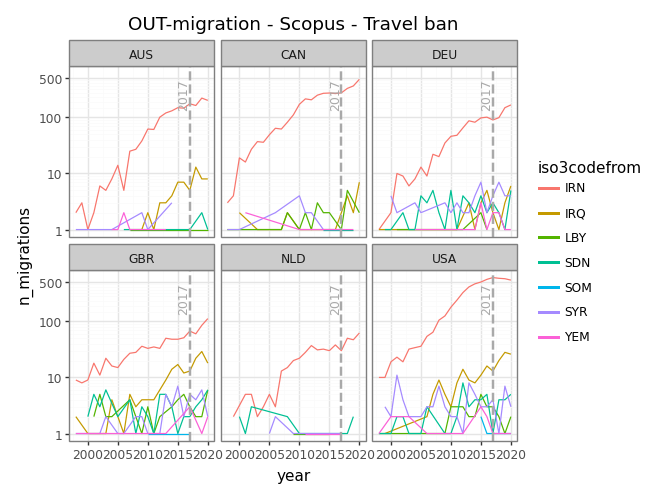

In [20]:
# Scopus
(
    gg.ggplot(ban2usa, gg.aes(x="year", y="n_migrations", color='iso3codefrom'))
    + gg.geom_line()
    + gg.geom_vline(gg.aes(xintercept=2017), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2016, y=500, label="2017", size=9, color="darkgray", va="top", angle=90)
    + gg.scale_y_log10(breaks=[1, 10, 100, 500])
    + gg.facet_wrap('iso3codeto')
    + gg.labs(title='OUT-migration - Scopus - Travel ban')
    + gg.theme_bw()
)

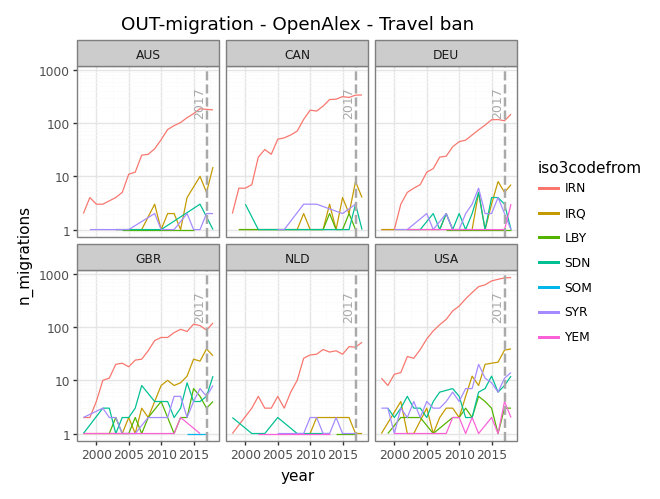

In [21]:
# OpenAlex
(
    gg.ggplot(op_ban2usa, gg.aes(x="year", y="n_migrations", color='iso3codefrom'))
    + gg.geom_line()
    + gg.geom_vline(gg.aes(xintercept=2017), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2016, y=500, label="2017", size=9, color="darkgray", va="top", angle=90)
    + gg.scale_y_log10(breaks=[1, 10, 100, 1000])
    + gg.facet_wrap('iso3codeto')
    + gg.labs(title='OUT-migration - OpenAlex - Travel ban')
    + gg.theme_bw()
)

# Example research questions 2: recent "INmigration" and "OUTmigration" to/from Ukraine and Russia

In this second example, we want to use the SMD data and see if in-migartion or out-mgration to/from Ukraine and Russia have changed during the past years which potentially could be associated with the ongoing conflict.

## Related literature to check
If you are interested to know more about this topic, check the following references:

- Wachs, J. (2023). Digital traces of brain drain: Developers during the Russian invasion of Ukraine. EPJ Data Science, 12(1), Article 1. https://doi.org/10.1140/epjds/s13688-023-00389-3
- Ganguli, I., & Waldinger, F. (2024). War and Science in Ukraine. Entrepreneurship and Innovation Policy and the Economy, 3, 165–188. https://doi.org/10.1086/727771
- Leasure, D. R., Kashyap, R., Rampazzo, F., Dooley, C. A., Elbers, B., Bondarenko, M., Verhagen, M., Frey, A., Yan, J., Akimova, E. T., Fatehkia, M., Trigwell, R., Tatem, A. J., Weber, I., & Mills, M. C. (2023). Nowcasting Daily Population Displacement in Ukraine through Social Media Advertising Data. Population and Development Review, n/a(n/a). https://doi.org/10.1111/padr.12558


# "OUTmigration" from Ukraine and Russia

In [22]:
selected_countries = ['UKR', 'RUS']
ukrrus_out = flow_data[(flow_data.iso3codefrom.isin(selected_countries))]
op_ukrrus_out = op_flow[(op_flow.iso3codefrom.isin(selected_countries))]

In [23]:
ukrrus_out.describe()

,n_migrations,year,gdp_per_capitafrom,gdp_per_capitato,populationfrom,populationto,paddedpopfrom,paddedpopto,number_of_inmigrationsfrom,number_of_inmigrationsto,number_of_outmigrationsfrom,number_of_outmigrationsto,avg_paddedpopfrom,avg_paddedpopto,avg_paddedpop_min,normalized_migration1,normalized_migration2
count,2376.000000,2376.000000,2376.000000,2376.000000,2.376000e+03,2.376000e+03,2376.000000,2.376000e+03,2376.000000,2376.000000,2376.000000,2376.000000,2376.000000,2.376000e+03,2376.000000,2376.000000,2376.000000
mean,13.943603,2009.558923,6213.590579,22960.542676,1.079191e+08,7.137605e+07,89497.027778,9.373242e+04,663.853535,1528.479798,825.732744,1541.636364,79341.858706,8.239956e+04,29036.385836,5613.099511,1785.931559
std,36.988388,6.760559,4682.105499,21602.865607,4.730745e+07,2.075219e+08,64310.644882,2.207315e+05,375.805102,3033.673816,434.693003,2934.484735,45700.447162,1.729834e+05,34429.051819,13261.706928,6862.086163
min,1.000000,1998.000000,631.910461,136.925716,4.468001e+07,1.075100e+04,13932.000000,6.000000e+00,153.000000,1.000000,216.000000,0.000000,20408.178571,3.000000e+00,3.000000,50.253782,3.263315
25%,1.000000,2004.000000,2158.461182,4793.910840,4.727869e+07,5.703569e+06,24993.000000,6.345000e+03,217.000000,128.000000,379.000000,125.000000,20408.178571,6.205857e+03,6205.857143,553.247823,108.178809
50%,4.000000,2010.000000,4017.806641,16414.503484,1.430182e+08,1.127420e+07,86523.000000,2.559900e+04,759.000000,561.500000,908.000000,521.000000,114765.607143,2.535504e+04,20408.178571,1195.131164,337.648809
75%,12.000000,2016.000000,10658.913086,38162.586891,1.452451e+08,5.842168e+07,123653.000000,8.245900e+04,1003.000000,1485.000000,1132.000000,1529.000000,114765.607143,6.993186e+04,25393.464286,3474.588472,1024.650968
max,597.000000,2020.000000,15941.448242,176891.886538,1.476708e+08,1.411100e+09,212953.000000,2.251676e+06,1247.000000,24990.000000,1709.000000,23310.000000,114765.607143,1.017913e+06,114765.607143,210084.033613,166713.346404


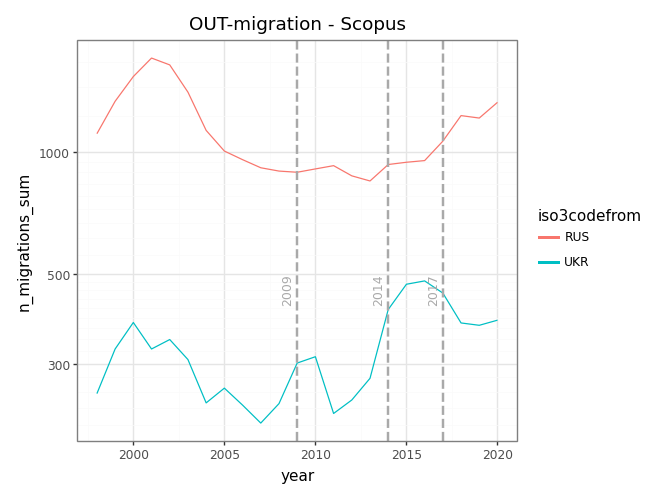

In [24]:
# Scopus
(
    gg.ggplot((
        ukrrus_out
        .groupby(['year', 'iso3codefrom'])
        .n_migrations.sum()
        .reset_index()
        .rename(columns={'n_migrations':'n_migrations_sum'})
    ), gg.aes(x="year", y="n_migrations_sum", color='iso3codefrom'))
    + gg.geom_line()
    + gg.geom_vline(gg.aes(xintercept=2017), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2016.5, y=500, label="2017", size=9, color="darkgray", va="top", angle=90)
    + gg.geom_vline(gg.aes(xintercept=2014), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2013.5, y=500, label="2014", size=9, color="darkgray", va="top", angle=90)
    + gg.geom_vline(gg.aes(xintercept=2009), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2008.5, y=500, label="2009", size=9, color="darkgray", va="top", angle=90)
    + gg.labs(title='OUT-migration - Scopus')
    + gg.theme_bw()
    + gg.scale_y_log10()
  )

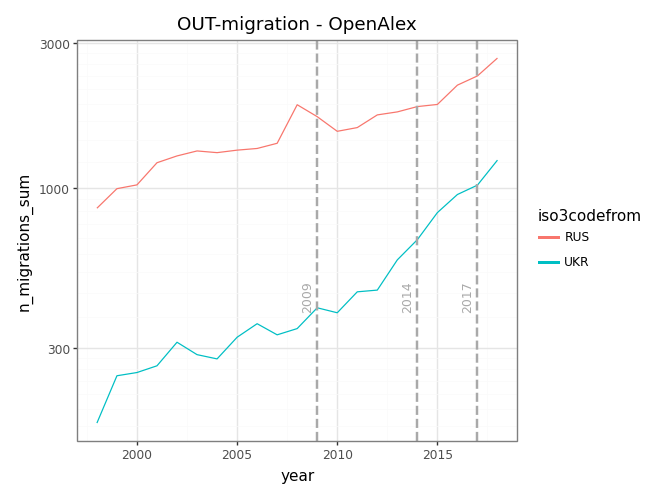

In [25]:
# OpenAlex
(
    gg.ggplot((
        op_ukrrus_out
        .groupby(['year', 'iso3codefrom'])
        .n_migrations.sum()
        .reset_index()
        .rename(columns={'n_migrations':'n_migrations_sum'})
    ), gg.aes(x="year", y="n_migrations_sum", color='iso3codefrom'))
    + gg.geom_line()
    + gg.geom_vline(gg.aes(xintercept=2017), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2016.5, y=500, label="2017", size=9, color="darkgray", va="top", angle=90)
    + gg.geom_vline(gg.aes(xintercept=2014), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2013.5, y=500, label="2014", size=9, color="darkgray", va="top", angle=90)
    + gg.geom_vline(gg.aes(xintercept=2009), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2008.5, y=500, label="2009", size=9, color="darkgray", va="top", angle=90)
    + gg.labs(title='OUT-migration - OpenAlex')
    + gg.theme_bw()
    + gg.scale_y_log10()
)

# "INmigration" to Ukraine and Russia

In [26]:
selected_countries = ['UKR', 'RUS']
ukrrus_in = flow_data[(flow_data.iso3codeto.isin(selected_countries))]
op_ukrrus_in = op_flow[(op_flow.iso3codeto.isin(selected_countries))]

In [27]:
ukrrus_in.describe()

,n_migrations,year,gdp_per_capitafrom,gdp_per_capitato,populationfrom,populationto,paddedpopfrom,paddedpopto,number_of_inmigrationsfrom,number_of_inmigrationsto,number_of_outmigrationsfrom,number_of_outmigrationsto,avg_paddedpopfrom,avg_paddedpopto,avg_paddedpop_min,normalized_migration1,normalized_migration2
count,2185.000000,2185.000000,2185.000000,2185.000000,2.185000e+03,2.185000e+03,2.185000e+03,2185.000000,2185.000000,2185.00000,2185.000000,2185.000000,2.185000e+03,2185.000000,2185.000000,2185.000000,2185.000000
mean,11.933181,2009.656751,22634.599205,6451.210692,7.538582e+07,1.112873e+08,9.821985e+04,94050.567963,1596.245767,691.63341,1615.718078,849.654005,8.699506e+04,82593.394655,30446.021333,6317.991450,1595.487508
std,28.810994,6.763758,20773.423160,4696.797043,2.162020e+08,4.630965e+07,2.271218e+05,64818.005851,3136.687654,372.41657,3030.733646,425.930243,1.792804e+05,44738.708381,35500.587769,13611.153859,6248.064881
min,1.000000,1998.000000,136.925716,631.910461,1.086900e+04,4.468001e+07,6.000000e+00,13932.000000,0.000000,153.00000,1.000000,216.000000,3.000000e+00,20408.178571,3.000000,49.015836,1.966901
25%,1.000000,2004.000000,4739.794312,2366.494141,6.175338e+06,4.797951e+07,6.914000e+03,27273.000000,139.000000,228.00000,141.000000,380.000000,6.442296e+03,20408.178571,6442.296296,553.685330,85.672066
50%,3.000000,2010.000000,16446.164718,4102.364746,1.115941e+07,1.430496e+08,2.737300e+04,88056.000000,574.000000,769.00000,547.000000,915.000000,2.539346e+04,114765.607143,20408.178571,1265.804982,234.488896
75%,10.000000,2016.000000,37812.895020,10658.913086,5.943885e+07,1.452451e+08,8.835600e+04,136775.000000,1575.000000,1034.00000,1576.000000,1132.000000,9.395439e+04,114765.607143,27126.428571,4063.719116,751.778979
max,337.000000,2020.000000,172823.607795,15941.448242,1.411100e+09,1.476708e+08,2.251676e+06,212953.000000,24990.000000,1247.00000,23310.000000,1709.000000,1.017913e+06,114765.607143,114765.607143,154639.175258,155418.994066


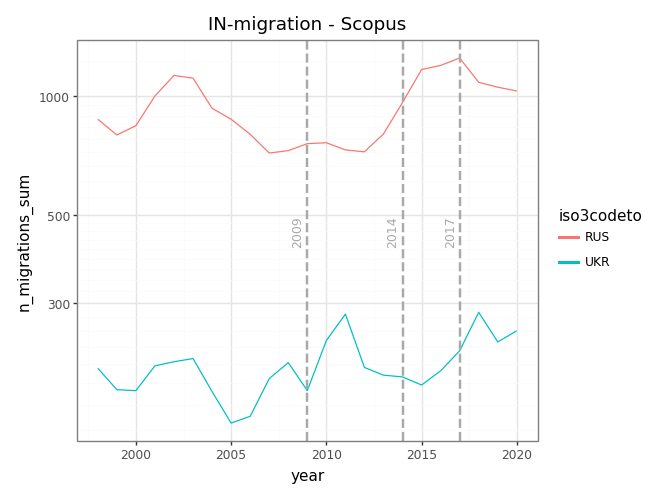

In [28]:
# Scopus
(
    gg.ggplot((
        ukrrus_in
        .groupby(['year', 'iso3codeto'])
        .n_migrations.sum()
        .reset_index()
        .rename(columns={'n_migrations':'n_migrations_sum'})
    ), gg.aes(x="year", y="n_migrations_sum", color='iso3codeto'))
    + gg.geom_line()
    + gg.geom_vline(gg.aes(xintercept=2017), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2016.5, y=500, label="2017", size=9, color="darkgray", va="top", angle=90)
    + gg.geom_vline(gg.aes(xintercept=2014), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2013.5, y=500, label="2014", size=9, color="darkgray", va="top", angle=90)
    + gg.geom_vline(gg.aes(xintercept=2009), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2008.5, y=500, label="2009", size=9, color="darkgray", va="top", angle=90)
    + gg.labs(title='IN-migration - Scopus')
    + gg.theme_bw()
    + gg.scale_y_log10()
)

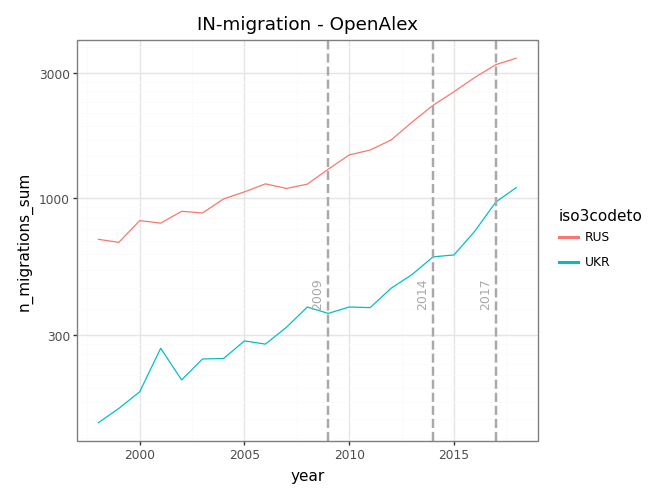

In [29]:
# OpenAlex
(
    gg.ggplot((
        op_ukrrus_in
        .groupby(['year', 'iso3codeto'])
        .n_migrations.sum()
        .reset_index()
        .rename(columns={'n_migrations':'n_migrations_sum'})
    ), gg.aes(x="year", y="n_migrations_sum", color='iso3codeto'))
    + gg.geom_line()
    + gg.geom_vline(gg.aes(xintercept=2017), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2016.5, y=500, label="2017", size=9, color="darkgray", va="top", angle=90)
    + gg.geom_vline(gg.aes(xintercept=2014), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2013.5, y=500, label="2014", size=9, color="darkgray", va="top", angle=90)
    + gg.geom_vline(gg.aes(xintercept=2009), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2008.5, y=500, label="2009", size=9, color="darkgray", va="top", angle=90)
    + gg.labs(title='IN-migration - OpenAlex')
    + gg.theme_bw()
    + gg.scale_y_log10()
)